In [1]:
#!rm -rf org && git clone --filter=blob:none --sparse https://github.com/yugoguy/org.git
#!cd org && git sparse-checkout set dev/SSLVE && git checkout Latent-Variable-Evolution

In [1]:
import sys, os, glob
sys.path.insert(0, 'org/dev/SSLVE')
for f in sorted(glob.glob('org/dev/SSLVE/*.py')):
    print(f"Running: {f}")
    %run {f}

Running: org/dev/SSLVE\AgentModules.py
Running: org/dev/SSLVE\AuxLosses.py
Running: org/dev/SSLVE\BehaviorDescriptors.py
Running: org/dev/SSLVE\BehaviorMatchings.py
Running: org/dev/SSLVE\CMAME.py
Running: org/dev/SSLVE\Collectors.py
Running: org/dev/SSLVE\ExperimentUtils.py
Running: org/dev/SSLVE\LatentModules.py
Running: org/dev/SSLVE\Main.py
Running: org/dev/SSLVE\SearchPhases.py
Running: org/dev/SSLVE\VariationOperators.py


Architecture: [27, 64, 64, 8]
Weight dim: 6472
Fitness: -forward_sum
Latent dim: 64, Hidden: [256], Beta: 0.001
Device: cpu
Gait BD grid: [10, 10, 10, 10] (10000 bins)
Samples per step: 500
Warmup threshold: 4096
Operators: ['pse_mut', 'pse_line', 'lve_mut', 'lve_cross', 'std_support_lve']
Warmup operators: ['pse_mut', 'pse_line']
BinPred gamma: 0.001
MixBinPred gamma: 0.001, alpha: [-0.1, 1.1]
Mode: SSLVE


--- SSLVE Step 1/200 ---
  Operator ratio - pse_mut: 500/500 (100%), pse_line: 0/500 (0%)
Collecting: 500/500 [127s elapsed, 0s remaining]]
Archive: 182, Bins: 124, Coverage: 0.0124, Fitness min/mean/max: -80.04/-3.79/50.81
QD-score: 62412.2281

--- SSLVE Step 2/200 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [206s elapsed, 0s remaining]]
Archive: 429, Bins: 298, Coverage: 0.0298, Fitness min/mean/max: -80.04/-2.08/98.71
QD-score: 150148.1181

--- SSLVE Step 3/200 ---
  Operator ratio - pse_mut: 59/500 (12%), pse_line: 441/500 (88%)
Co

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Collecting: 500/500 [338s elapsed, 0s remaining]]]
Archive: 12807, Bins: 5331, Coverage: 0.5331, Fitness min/mean/max: -361.90/-21.10/116.18
QD-score: 2801496.6336
Epoch 10/50 | Train Total: 0.0008, Recon: 0.0004, KL: 0.4589, bin_pred: 0.0485, mix_bin_pred: 0.0363 | Val Total: 0.0008
Epoch 20/50 | Train Total: 0.0008, Recon: 0.0004, KL: 0.4597, bin_pred: 0.0487, mix_bin_pred: 0.0361 | Val Total: 0.0009
Epoch 30/50 | Train Total: 0.0008, Recon: 0.0004, KL: 0.4561, bin_pred: 0.0489, mix_bin_pred: 0.0362 | Val Total: 0.0009
Epoch 40/50 | Train Total: 0.0008, Recon: 0.0004, KL: 0.4562, bin_pred: 0.0492, mix_bin_pred: 0.0368 | Val Total: 0.0009
Epoch 50/50 | Train Total: 0.0008, Recon: 0.0004, KL: 0.4641, bin_pred: 0.0486, mix_bin_pred: 0.0360 | Val Total: 0.0009

--- SSLVE Step 118/200 ---
  Operator ratio - pse_mut: 32/500 (6%), pse_line: 102/500 (20%), lve_mut: 311/500 (62%), lve_cross: 30/500 (6%), std_support_lve: 25/500 (5%)
Collecting: 500/500 [339s elapsed, 0s remaining]]]
Archive: 

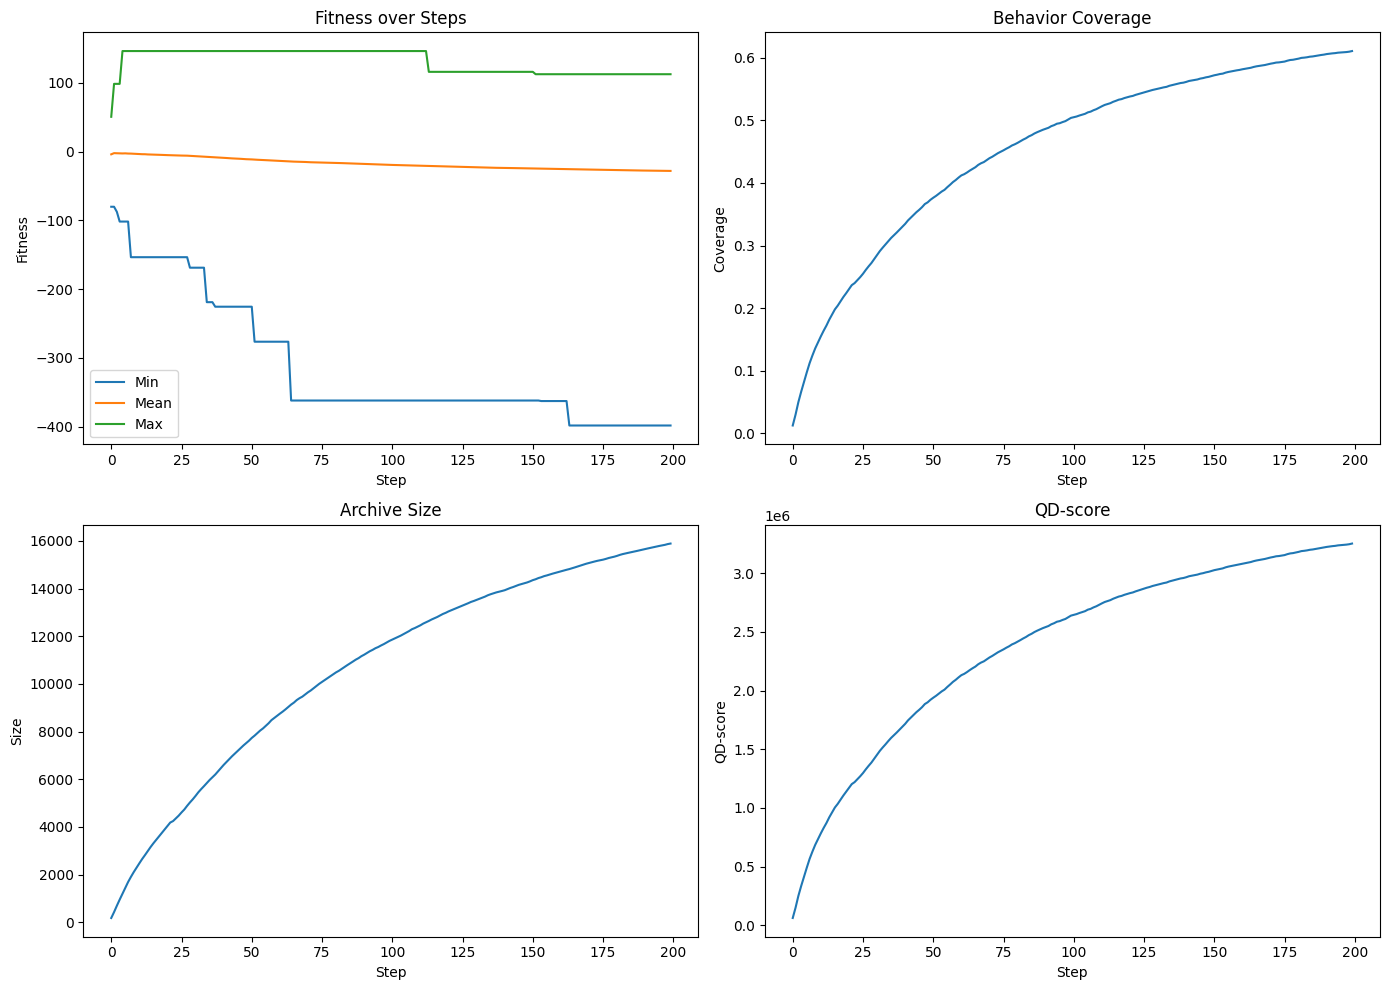

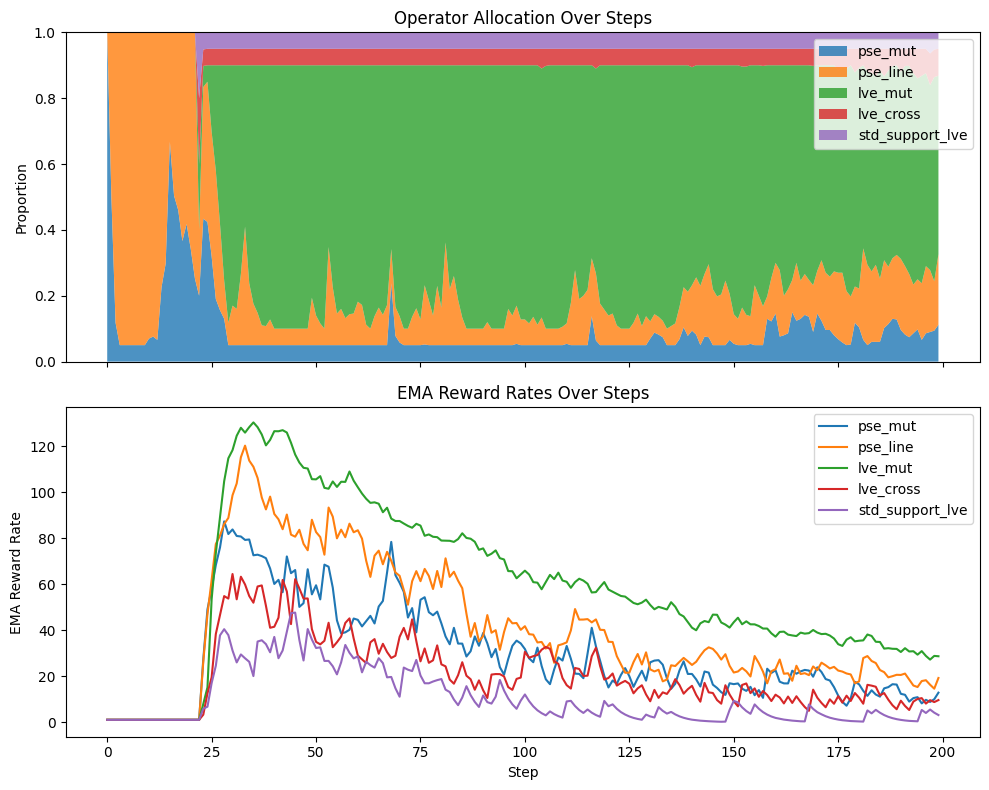

In [3]:
#@title AntGaitUni LVE Any (Flow + AuxLoss)
import numpy as np
import random
import torch

# =============================================================================
# Hyperparameters
# =============================================================================
ARCHITECTURE = [27, 64, 64, 8]  #@param
OUTPUT_ACTIVATION = 'tanh'  #@param {type:"string"}
MAX_STEPS = 500  #@param {type:"integer"}
N_EPISODES = 3  #@param {type:"integer"}
CTRL_COST_WEIGHT = 0.5  #@param {type:"number"}

# --- Gait BD Grid ---
BIN_SIZES = [10, 10, 10, 10]  #@param

# --- Fitness ---
TOP_K = 3  #@param {type:"integer"}
MAX_FITNESS = 500.0  #@param {type:"number"}

# --- Variation Operators ---
USE_PSE_MUT = True  #@param {type:"boolean"}
USE_PSE_LINE = True  #@param {type:"boolean"}
USE_LVE_MUT = True  #@param {type:"boolean"}
USE_LVE_CROSS = True  #@param {type:"boolean"}
USE_STD_SUPPORT_LVE = True  #@param {type:"boolean"}
GREEDY_MEM = True  #@param {type:"boolean"}

PSE_MUT_SIGMA = 0.05  #@param {type:"number"}
LVE_MUT_SIGMA = 0.05  #@param {type:"number"}
STD_SUPPORT_LO = -2.0  #@param {type:"number"}
STD_SUPPORT_HI = 2.0  #@param {type:"number"}

# --- Warmup Operators ---
WARMUP_PSE_MUT = True  #@param {type:"boolean"}
WARMUP_PSE_LINE = True  #@param {type:"boolean"}

N_TOTAL = 500  #@param {type:"integer"}
WARMUP_THRESHOLD = 4096  #@param {type:"integer"}
EMA_ALPHA = 0.25  #@param {type:"number"}
TEMPERATURE = 10  #@param {type:"number"}
MIN_PROPORTION = 0.05  #@param {type:"number"}

# --- Latent Module ---
USE_FLOW_PRIOR = False  #@param {type:"boolean"}
LATENT_DIM = 64  #@param {type:"integer"}
HIDDEN_DIMS = [256]  #@param
BETA = 1e-3  #@param {type:"number"}
NUM_FLOWS = 3  #@param {type:"integer"}
FLOW_HIDDEN = 128  #@param {type:"integer"}
FLOW_HIDDEN_LAYERS = 2  #@param {type:"integer"}
EPOCHS = 50  #@param {type:"integer"}
BATCH_SIZE = 1024  #@param {type:"integer"}
LR = 1e-3  #@param {type:"number"}

# --- Aux Losses ---
USE_BIN_PRED = True  #@param {type:"boolean"}
GAMMA_BIN_PRED = 1e-3  #@param {type:"number"}
USE_MIX_BIN_PRED = True  #@param {type:"boolean"}
GAMMA_MIX_BIN_PRED = 1e-3  #@param {type:"number"}
MIX_ALPHA_LO = -0.1  #@param {type:"number"}
MIX_ALPHA_HI = 1.1  #@param {type:"number"}

N_STEPS = 200  #@param {type:"integer"}

# --- Checkpoint ---
CHECKPOINT_PATH = ''  #@param {type:"string"}

SEED = 123  #@param {type:"integer"}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# =============================================================================
# Setup
# =============================================================================
weight_dim = MLP_Agent(ARCHITECTURE, output_activation=OUTPUT_ACTIVATION).get_weight_dim()

fitness_fn = lambda info: -info['forward_sum']

collector = AntOmniCollector(
    max_steps=MAX_STEPS,
    n_episodes=N_EPISODES,
    ctrl_cost_weight=CTRL_COST_WEIGHT,
    seed=SEED,
)
bd = AntGaitBD(bin_sizes=BIN_SIZES)
bm = MAPElitesBM(behavior_descriptor=bd, fitness_fn=fitness_fn, top_k=TOP_K, max_fitness=MAX_FITNESS)

operators = []
translate_fn = None
if USE_PSE_MUT:
    operators.append(PSEMut(sigma=PSE_MUT_SIGMA, greedy_mem=GREEDY_MEM))
if USE_PSE_LINE:
    operators.append(PSELine(greedy_mem=GREEDY_MEM))
if USE_LVE_MUT:
    operators.append(LVEMut(sigma=LVE_MUT_SIGMA, greedy_mem=GREEDY_MEM))
if USE_LVE_CROSS:
    operators.append(LVECross(greedy_mem=GREEDY_MEM))
assert len(operators) > 0

warmup_operators = []
if WARMUP_PSE_MUT:
    warmup_operators.append(PSEMut(sigma=PSE_MUT_SIGMA, greedy_mem=GREEDY_MEM))
if WARMUP_PSE_LINE:
    warmup_operators.append(PSELine(greedy_mem=GREEDY_MEM))
assert len(warmup_operators) > 0

aux_losses = []
if USE_BIN_PRED:
    aux = BinPred(behavior_descriptor=bd, latent_dim=LATENT_DIM, output_dim=4)
    aux_losses.append((GAMMA_BIN_PRED, aux))

if USE_MIX_BIN_PRED:
    mix_aux = MixBinPred(
        behavior_descriptor=bd, latent_dim=LATENT_DIM, output_dim=4,
        alpha_lo=MIX_ALPHA_LO, alpha_hi=MIX_ALPHA_HI,
    )
    aux_losses.append((GAMMA_MIX_BIN_PRED, mix_aux))

if USE_FLOW_PRIOR:
    lm = BaseFlowVAE(
        input_dim=weight_dim,
        latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS,
        beta=BETA,
        num_flows=NUM_FLOWS,
        flow_hidden=FLOW_HIDDEN,
        flow_hidden_layers=FLOW_HIDDEN_LAYERS,
        aux_losses=aux_losses,
    )
    translate_fn = lm.translate
    if USE_MIX_BIN_PRED:
        mix_aux.to_base_fn = lambda z: lm.flow.f(z)[0]
        mix_aux.from_base_fn = lm.flow.f_inv
else:
    lm = BaseBetaVAE(
        input_dim=weight_dim,
        latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS,
        beta=BETA,
        aux_losses=aux_losses,
    )

if USE_STD_SUPPORT_LVE:
    operators.append(StandardNormalSupportLVE(lo=STD_SUPPORT_LO, hi=STD_SUPPORT_HI, translate_fn=translate_fn))

sp = BoltzmannMix(
    agent_class=MLP_Agent,
    architecture=ARCHITECTURE,
    agent_kwargs={'output_activation': OUTPUT_ACTIVATION},
    operators=operators,
    warmup_operators=warmup_operators,
    n_total=N_TOTAL,
    warmup_threshold=WARMUP_THRESHOLD,
    ema_alpha=EMA_ALPHA,
    temperature=TEMPERATURE,
    min_proportion=MIN_PROPORTION,
)

orchestrator = SSLVE(
    search_phase=sp,
    collector=collector,
    behavior_matching=bm,
    latent_module=lm,
    device=DEVICE,
)

if CHECKPOINT_PATH:
    load_checkpoint(CHECKPOINT_PATH, bm, orchestrator.history, sp=sp, lm=lm, device=DEVICE)
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
    print(f"Archive size: {bm.archive_size()}, Coverage: {bm.coverage():.4f}")

# =============================================================================
# Run
# =============================================================================
print(f"Architecture: {ARCHITECTURE}")
print(f"Weight dim: {weight_dim}")
print(f"Fitness: -forward_sum")
if USE_FLOW_PRIOR:
    print(f"Flow prior: {NUM_FLOWS} flows, hidden: {FLOW_HIDDEN}x{FLOW_HIDDEN_LAYERS}")
print(f"Latent dim: {LATENT_DIM}, Hidden: {HIDDEN_DIMS}, Beta: {BETA}")
print(f"Device: {DEVICE}")
print(f"Gait BD grid: {BIN_SIZES} ({bd.total_bins()} bins)")
print(f"Samples per step: {N_TOTAL}")
print(f"Warmup threshold: {WARMUP_THRESHOLD}")
print(f"Operators: {[op.name for op in operators]}")
print(f"Warmup operators: {[op.name for op in warmup_operators]}")
if USE_BIN_PRED:
    print(f"BinPred gamma: {GAMMA_BIN_PRED}")
if USE_MIX_BIN_PRED:
    print(f"MixBinPred gamma: {GAMMA_MIX_BIN_PRED}, alpha: [{MIX_ALPHA_LO}, {MIX_ALPHA_HI}]")
print(f"Mode: SSLVE")
print()

train_kwargs = {
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'verbose': True,
}
histories = orchestrator.run(n_steps=N_STEPS, train_kwargs=train_kwargs)

f_min, f_mean, f_max = bm.fitness_stats()
print(f"\nFinal archive size: {bm.archive_size()}")
print(f"Final coverage: {bm.coverage():.4f}")
print(f"Best fitness: {f_min:.4f}")
print(f"QD-score: {bm.qd_score():.4f}")

orchestrator.plot_history()
sp.plot_allocation()

In [4]:
save_dir = './archive/'

run_dir = save_dir + 'LVE-Proposed_seed123/'
os.makedirs(run_dir, exist_ok=True)

save_checkpoint(run_dir, bm, orchestrator.history, sp=sp, lm=lm)